# 🦷 Klasifikasi Penyakit Gigi: Caries vs Gingivitas

| Item | Detail |
|------|--------|
| **Model** | MobileNetV2 Transfer Learning + Fine-tuning |
| **Kelas** | `Caries` \| `Gingivitas` |
| **Framework** | TensorFlow 2.x + MLflow |
| **Environment** | VS Code / JupyterLab |


---
## ⚙️ CELL 0 — Konfigurasi Terpusat
> **Ubah hanya di sini.** Semua cell lain membaca dari variabel ini.

In [ ]:
from pathlib import Path
import mlflow

# ─── PATH ────────────────────────────────────────────────────────
PROJECT_DIR  = Path(r"D:/Amikom Kuliah/sem 6/datamining/data_dental2.0")
ZIP_PATH     = Path(r"D:/Amikom Kuliah/sem 6/datamining/Caries.ZIP")
DATA_ROOT    = Path(r"D:/Amikom Kuliah/sem 6/datamining/data_extracted")
SPLIT_ROOT   = PROJECT_DIR / "dental_split"
MODEL_DIR    = PROJECT_DIR / "models"
RESULT_DIR   = PROJECT_DIR / "results"

# ─── REPRODUCIBILITY ─────────────────────────────────────────────
SEED = 42

# ─── DATA ────────────────────────────────────────────────────────
IMG_SIZE         = (224, 224)
BATCH_SIZE       = 32
TRAIN_RATIO      = 0.70
VAL_RATIO        = 0.15
TEST_RATIO       = 0.15
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# ─── MODEL ───────────────────────────────────────────────────────
UNFREEZE_LAST = 30
DROPOUT_RATE  = 0.4
DENSE_UNITS   = 128

# ─── TRAINING ────────────────────────────────────────────────────
LR_PHASE1       = 1e-3
LR_PHASE2       = 1e-5
EPOCHS_PHASE1   = 20
EPOCHS_PHASE2   = 30
EARLY_STOP_PAT1 = 6
EARLY_STOP_PAT2 = 8
REDUCE_LR_PAT1  = 3
REDUCE_LR_PAT2  = 4

# ─── MLFLOW ──────────────────────────────────────────────────────
MLFLOW_EXPERIMENT = "dental_classification_mobilenetv2"
mlflow.set_tracking_uri((PROJECT_DIR / "mlruns").as_uri())
mlflow.set_experiment(MLFLOW_EXPERIMENT)

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9, "Rasio harus 1.0"

print(f"Tracking URI : {mlflow.get_tracking_uri()}")
print(f"Experiment   : {MLFLOW_EXPERIMENT}")
print("Jalankan di terminal: mlflow ui --backend-store-uri ./mlruns")
print("✓ Konfigurasi dimuat")

---
## 📦 CELL 1 — Import Library

In [2]:
import os
import json
import zipfile
import shutil
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

import mlflow
import mlflow.tensorflow

# ─── Seed global ─────────────────────────────────────────────────
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TF version  : {tf.__version__}")
print(f"GPU tersedia: {tf.config.list_physical_devices('GPU')}")
print(f"Seed        : {SEED}")

ModuleNotFoundError: No module named 'tensorflow'

---
## 📁 CELL 2 — Buat Folder & Ekstrak Dataset

In [5]:
for folder in [DATA_ROOT, SPLIT_ROOT, MODEL_DIR, RESULT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Ekstrak jika ZIP tersedia dan folder belum terisi
if ZIP_PATH.exists() and not any(DATA_ROOT.iterdir()):
    print("Mengekstrak dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATA_ROOT)
    print("✓ Ekstrak selesai")
elif not ZIP_PATH.exists():
    print("ZIP tidak ditemukan — pastikan dataset sudah ada di DATA_ROOT")
else:
    print("✓ Dataset sudah ada, melewati ekstrak")

print(f"\nIsi DATA_ROOT ({DATA_ROOT.resolve()}):")
for item in sorted(DATA_ROOT.iterdir()):
    if item.is_dir():
        n_imgs = len([p for p in item.rglob("*") if p.suffix.lower() in VALID_EXTENSIONS])
        print(f"  📁 {item.name}/  ({n_imgs} gambar)")

✓ Dataset sudah ada, melewati ekstrak

Isi DATA_ROOT (D:\Amikom Kuliah\sem 6\datamining\data_extracted):
  📁 Caries/  (800 gambar)
  📁 Gingivitas/  (585 gambar)


---
## 🔍 CELL 3 — Validasi Kelas & EDA

Kelas ditemukan (2 kelas): ['Caries', 'Gingivitas']
  Caries: 800 gambar (57.8%)
  Gingivitas: 585 gambar (42.2%)

Total          : 1385
Imbalance ratio: 1.37x


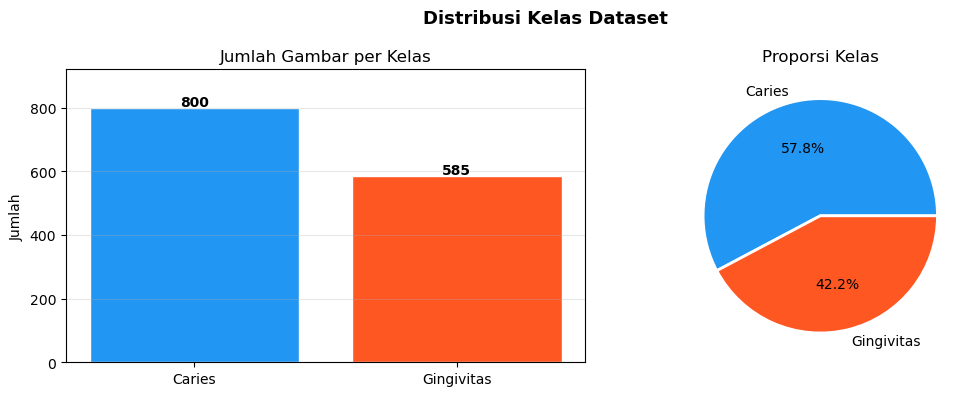


⚠️  Limitation:
  - Dataset kecil (<2000 gambar) — Transfer Learning wajib
  - Tidak ada metadata pasien (usia, jenis kelamin, etnis)
  - Tidak diketahui apakah gambar dari satu klinik atau multi-sumber


In [6]:
BASE_DIR = DATA_ROOT  # ubah jika ada subfolder tambahan setelah ekstrak

all_classes = sorted([d.name for d in BASE_DIR.iterdir() if d.is_dir()])
print(f"Kelas ditemukan ({len(all_classes)} kelas): {all_classes}")

class_counts = {}
for cls in all_classes:
    imgs = [p for p in (BASE_DIR / cls).rglob("*") if p.suffix.lower() in VALID_EXTENSIONS]
    class_counts[cls] = len(imgs)

total = sum(class_counts.values())
imbalance_ratio = max(class_counts.values()) / min(class_counts.values())

for cls, count in class_counts.items():
    print(f"  {cls}: {count} gambar ({count/total*100:.1f}%)")
print(f"\nTotal          : {total}")
print(f"Imbalance ratio: {imbalance_ratio:.2f}x")

# ─── Visualisasi distribusi ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Distribusi Kelas Dataset", fontsize=13, fontweight="bold")

colors = ["#2196F3", "#FF5722"]
bars = axes[0].bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor="white")
axes[0].set_title("Jumlah Gambar per Kelas")
axes[0].set_ylabel("Jumlah")
axes[0].set_ylim(0, max(class_counts.values()) * 1.15)
for bar, count in zip(bars, class_counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(count), ha="center", fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

axes[1].pie(class_counts.values(), labels=class_counts.keys(),
            autopct="%1.1f%%", colors=colors,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Proporsi Kelas")

plt.tight_layout()
plt.savefig(RESULT_DIR / "eda_distribusi.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n⚠️  Limitation:")
print("  - Dataset kecil (<2000 gambar) — Transfer Learning wajib")
print("  - Tidak ada metadata pasien (usia, jenis kelamin, etnis)")
print("  - Tidak diketahui apakah gambar dari satu klinik atau multi-sumber")

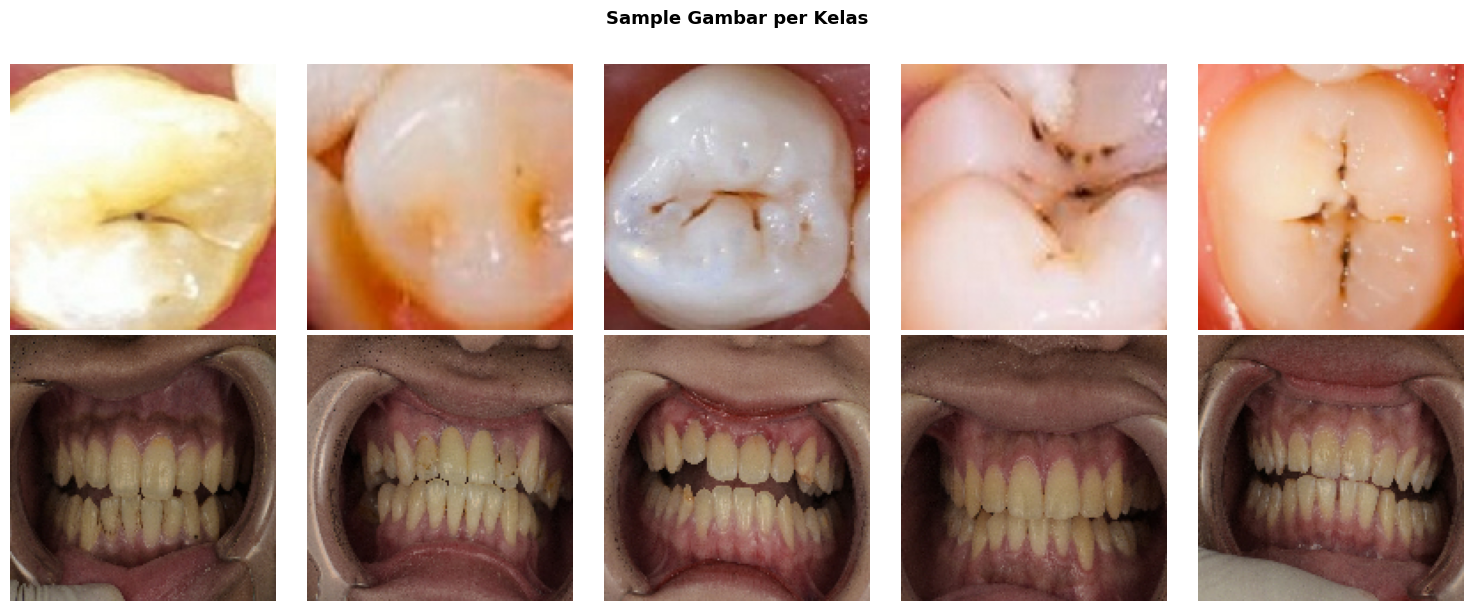

In [7]:
N_SAMPLE = 5
fig, axes = plt.subplots(len(all_classes), N_SAMPLE,
                         figsize=(3*N_SAMPLE, 3*len(all_classes)))
fig.suptitle("Sample Gambar per Kelas", fontsize=13, fontweight="bold", y=1.01)

rng = np.random.default_rng(SEED)
for row, cls in enumerate(all_classes):
    all_imgs = [p for p in (BASE_DIR / cls).rglob("*")
                if p.suffix.lower() in VALID_EXTENSIONS]
    samples = rng.choice(all_imgs, size=min(N_SAMPLE, len(all_imgs)), replace=False)
    for col, img_path in enumerate(samples):
        ax = axes[row][col]
        ax.imshow(load_img(img_path, target_size=(150, 150)))
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(cls, fontsize=11, fontweight="bold", rotation=90, labelpad=10)
            ax.yaxis.set_label_position("left")

plt.tight_layout()
plt.savefig(RESULT_DIR / "eda_samples.png", dpi=120, bbox_inches="tight")
plt.show()

---
## ✂️ CELL 4 — Split Train / Val / Test

**Fix:** `test_size` pada split kedua sekarang benar menggunakan proporsi TEST dari temp.


In [8]:
# Bersihkan split lama
if SPLIT_ROOT.exists():
    shutil.rmtree(SPLIT_ROOT)

split_summary = {}
for cls in all_classes:
    image_files = sorted([
        p for p in (BASE_DIR / cls).rglob("*")
        if p.suffix.lower() in VALID_EXTENSIONS
    ])

    # Split 1: train vs (val+test)
    train_files, temp_files = train_test_split(
        image_files,
        test_size=(VAL_RATIO + TEST_RATIO),
        random_state=SEED,
        shuffle=True
    )

    # Split 2: val vs test — test_size adalah proporsi TEST dari temp
    test_ratio_from_temp = TEST_RATIO / (VAL_RATIO + TEST_RATIO)
    val_files, test_files = train_test_split(
        temp_files,
        test_size=test_ratio_from_temp,
        random_state=SEED
    )

    assert len(train_files) + len(val_files) + len(test_files) == len(image_files)

    for split_name, files in [("train", train_files), ("val", val_files), ("test", test_files)]:
        dest = SPLIT_ROOT / split_name / cls
        dest.mkdir(parents=True, exist_ok=True)
        for src in files:
            shutil.copy2(src, dest / src.name)

    n_total = len(image_files)
    split_summary[cls] = {"train": len(train_files), "val": len(val_files), "test": len(test_files)}
    print(f"{cls}: {len(train_files)} train ({len(train_files)/n_total*100:.0f}%) "
          f"| {len(val_files)} val ({len(val_files)/n_total*100:.0f}%) "
          f"| {len(test_files)} test ({len(test_files)/n_total*100:.0f}%)")

n_train = sum(v["train"] for v in split_summary.values())
n_val   = sum(v["val"]   for v in split_summary.values())
n_test  = sum(v["test"]  for v in split_summary.values())
print(f"\nTotal → train: {n_train} | val: {n_val} | test: {n_test}")
print("✓ Split selesai")

Caries: 560 train (70%) | 120 val (15%) | 120 test (15%)
Gingivitas: 409 train (70%) | 88 val (15%) | 88 test (15%)

Total → train: 969 | val: 208 | test: 208
✓ Split selesai


---
## 🔄 CELL 5 — tf.data Pipeline

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    """Baca gambar → resize → preprocess_input MobileNetV2."""
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess_input(img)  # range [-1, 1] untuk MobileNetV2
    return img, label

@tf.function
def augment(img, label):
    """Augmentasi hanya untuk training set — pure TF ops, aman di @tf.function."""
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    # rot90 dengan k acak: rotasi 0/90/180/270 derajat
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    img = tf.image.rot90(img, k=k)
    return img, label

def make_dataset(split_dir, class_map, training=False):
    """
    Buat tf.data.Dataset dari folder split.
    class_map: dict {class_name: int_label}
    """
    paths, labels = [], []
    for cls_name, label_idx in class_map.items():
        cls_dir = split_dir / cls_name
        for ext in VALID_EXTENSIONS:
            for p in cls_dir.glob(f"*{ext}"):
                paths.append(str(p))
                labels.append(label_idx)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds, paths, labels

# Buat class map (sorted agar deterministik)
class_map   = {cls: idx for idx, cls in enumerate(sorted(all_classes))}
class_names = sorted(all_classes)
print("Class map:", class_map)

train_ds, train_paths, train_labels = make_dataset(SPLIT_ROOT / "train", class_map, training=True)
val_ds,   val_paths,   val_labels   = make_dataset(SPLIT_ROOT / "val",   class_map, training=False)
test_ds,  test_paths,  test_labels  = make_dataset(SPLIT_ROOT / "test",  class_map, training=False)

print(f"\n✓ Dataset dibuat")
print(f"  Train: {len(train_paths)} gambar")
print(f"  Val  : {len(val_paths)} gambar")
print(f"  Test : {len(test_paths)} gambar")

Class map: {'Caries': 0, 'Gingivitas': 1}

✓ Dataset dibuat
  Train: 969 gambar
  Val  : 208 gambar
  Test : 208 gambar


---
## ⚖️ CELL 6 — Class Weight

In [10]:
# Hitung dari label training (bukan dari generator yang sudah berjalan)
y_train_labels = np.array(train_labels)

cw_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weight_dict = dict(enumerate(cw_array))

print("Class weights:")
for k, v in class_weight_dict.items():
    print(f"  {class_names[k]}: {v:.4f}")

Class weights:
  Caries: 0.8652
  Gingivitas: 1.1846


---
## 🧠 CELL 7 — Bangun Model MobileNetV2

In [11]:
def build_model():
    """MobileNetV2 dengan classification head."""
    base = MobileNetV2(
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
        include_top=False,
        weights="imagenet"
    )
    base.trainable = False  # Freeze untuk Fase 1

    inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = base(inputs, training=False)   # training=False penting untuk BatchNorm base
    x = layers.GlobalAveragePooling2D()(x)

    # BN setelah Dense (sebelum aktivasi) lebih efektif
    x = layers.Dense(DENSE_UNITS)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(DROPOUT_RATE)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs, outputs)
    return model, base


model, base_model = build_model()
model.summary()

trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
total_p   = model.count_params()
print(f"\nTotal params     : {total_p:,}")
print(f"Trainable params : {trainable:,}  ({trainable/total_p*100:.1f}%)")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,593 (9.24 MB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 2,258,240 (8.61 MB)


Total params     : 2,422,593
Trainable params : 164,353  (6.8%)


---
## 🏋️ CELL 8 — Training Fase 1: Feature Extraction

In [12]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_PHASE1),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

callbacks_p1 = [
    keras.callbacks.ModelCheckpoint(
        str(MODEL_DIR / "best_phase1.keras"),
        monitor="val_auc", save_best_only=True, mode="max", verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=EARLY_STOP_PAT1,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=REDUCE_LR_PAT1,
        min_lr=1e-6, verbose=1
    )
]

# Semua fase dalam satu parent run MLflow
with mlflow.start_run(run_name="dental_full_training") as parent_run:
    mlflow.log_params({
        "model_base"        : "MobileNetV2",
        "img_size"          : str(IMG_SIZE),
        "batch_size"        : BATCH_SIZE,
        "seed"              : SEED,
        "train_ratio"       : TRAIN_RATIO,
        "dataset_caries"    : class_counts.get("Caries", 0),
        "dataset_gingivitas": class_counts.get("Gingivitas", 0),
        "unfreeze_last"     : UNFREEZE_LAST,
        "dropout_rate"      : DROPOUT_RATE,
        "preprocessing"     : "mobilenet_v2.preprocess_input",
    })

    print("=" * 50)
    print("FASE 1: Feature Extraction (base frozen)")
    print("=" * 50)

    with mlflow.start_run(run_name="phase1_feature_extraction", nested=True):
        mlflow.log_param("learning_rate", LR_PHASE1)
        mlflow.log_param("phase", "feature_extraction")
        history1 = model.fit(
            train_ds,
            epochs=EPOCHS_PHASE1,
            validation_data=val_ds,
            callbacks=callbacks_p1,
            class_weight=class_weight_dict
        )

    # Simpan parent_run_id untuk Cell 9
    parent_run_id = parent_run.info.run_id

print(f"\n✓ Fase 1 selesai. Parent run ID: {parent_run_id}")

FASE 1: Feature Extraction (base frozen)
Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9199 - auc: 0.9654 - loss: 0.1651
Epoch 1: val_auc improved from None to 1.00000, saving model to D:\Amikom Kuliah\sem 6\datamining\data_dental2.0\models\best_phase1.keras

Epoch 1: finished saving model to D:\Amikom Kuliah\sem 6\datamining\data_dental2.0\models\best_phase1.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.9773 - auc: 0.9986 - loss: 0.0557 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 8.7032e-04 - learning_rate: 0.0010
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0059
Epoch 2: val_auc did not improve from 1.00000
31/31 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0069 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 6.9146e-04 - learning_rate: 0.0010
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0038
Epoch 3: val_auc did not 

---
## 🔧 CELL 9 — Training Fase 2: Fine-tuning

In [13]:
# Unfreeze layer terakhir base model
base_model.trainable = True
freeze_until = len(base_model.layers) - UNFREEZE_LAST
for i, layer in enumerate(base_model.layers):
    layer.trainable = i >= freeze_until

n_unfrozen = sum(l.trainable for l in base_model.layers)
print(f"Layer yang di-unfreeze: {n_unfrozen}/{len(base_model.layers)}")

# Recompile dengan LR lebih kecil untuk fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_PHASE2),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

callbacks_p2 = [
    keras.callbacks.ModelCheckpoint(
        str(MODEL_DIR / "best_phase2.keras"),
        monitor="val_auc", save_best_only=True, mode="max", verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=EARLY_STOP_PAT2,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=REDUCE_LR_PAT2,
        min_lr=1e-7, verbose=1
    )
]

# Lanjutkan dari parent run yang sama
with mlflow.start_run(run_id=parent_run_id):
    print("=" * 50)
    print("FASE 2: Fine-tuning")
    print("=" * 50)

    with mlflow.start_run(run_name="phase2_fine_tuning", nested=True):
        mlflow.log_param("learning_rate", LR_PHASE2)
        mlflow.log_param("phase", "fine_tuning")
        mlflow.log_param("unfrozen_layers", n_unfrozen)
        history2 = model.fit(
            train_ds,
            epochs=EPOCHS_PHASE2,
            validation_data=val_ds,
            callbacks=callbacks_p2,
            class_weight=class_weight_dict
        )

print("\n✓ Fase 2 selesai")

Layer yang di-unfreeze: 30/154
FASE 2: Fine-tuning
Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9997 - auc: 1.0000 - loss: 0.0122
Epoch 1: val_auc improved from None to 1.00000, saving model to D:\Amikom Kuliah\sem 6\datamining\data_dental2.0\models\best_phase2.keras

Epoch 1: finished saving model to D:\Amikom Kuliah\sem 6\datamining\data_dental2.0\models\best_phase2.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.9990 - auc: 1.0000 - loss: 0.0122 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 1.9306e-04 - learning_rate: 1.0000e-05
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0048
Epoch 2: val_auc did not improve from 1.00000
31/31 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0047 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 1.1937e-04 - learning_rate: 1.0000e-05
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0041
Epoch 3

---
## 📈 CELL 10 — Plot Training History

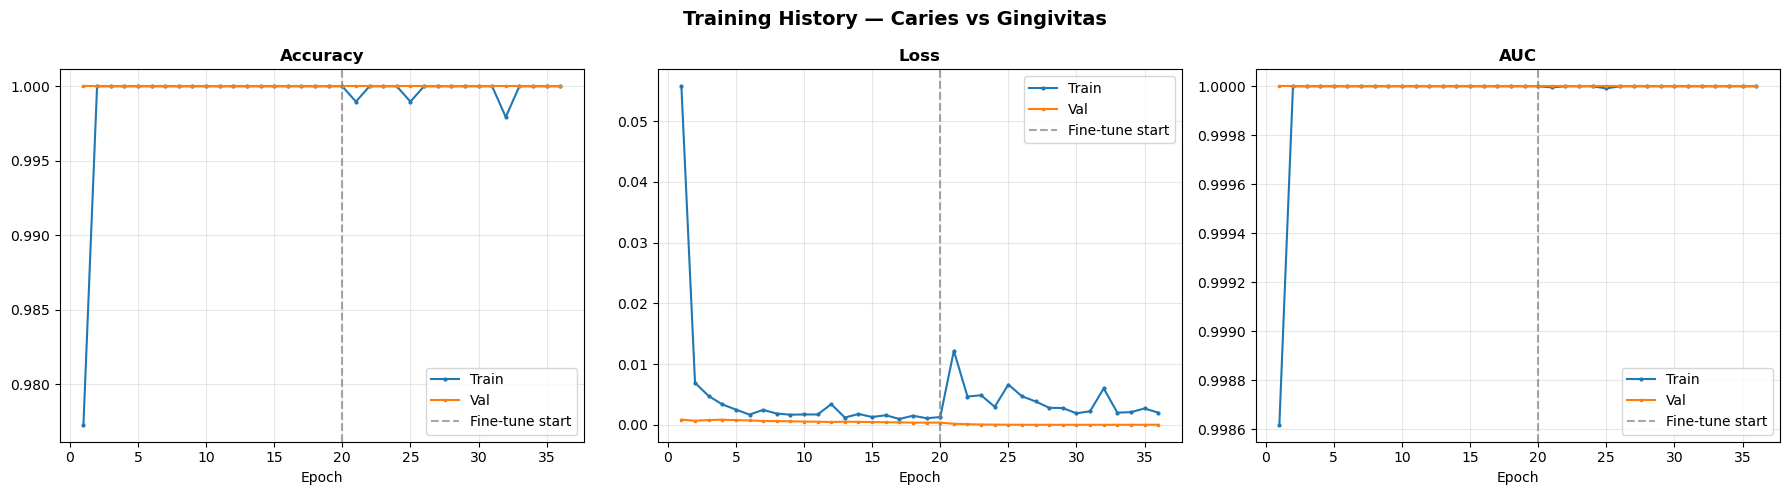

✓ Disimpan ke results/training_history.png


In [14]:
def merge_history(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history.get(key, [])
    return merged

hist = merge_history(history1, history2)
phase1_end = len(history1.history["loss"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training History — Caries vs Gingivitas", fontsize=14, fontweight="bold")

metrics_to_plot = [
    ("accuracy", "val_accuracy", "Accuracy"),
    ("loss",     "val_loss",     "Loss"),
    ("auc",      "val_auc",      "AUC"),
]

for ax, (train_key, val_key, title) in zip(axes, metrics_to_plot):
    epochs = range(1, len(hist[train_key]) + 1)
    ax.plot(epochs, hist[train_key], marker="o", markersize=2, label="Train", linewidth=1.5)
    ax.plot(epochs, hist[val_key],   marker="s", markersize=2, label="Val",   linewidth=1.5)
    ax.axvline(x=phase1_end, color="gray", linestyle="--", alpha=0.7, label="Fine-tune start")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULT_DIR / "training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Disimpan ke results/training_history.png")

---
## 🎯 CELL 11 — Cari Threshold Optimal dari Validation Set

> Threshold dicari **hanya** dari validation set. Test set tidak boleh disentuh sampai evaluasi akhir.

Best threshold (val weighted-F1): 0.10
Best val weighted-F1            : 1.0000
[INFO] Threshold dipilih dari VAL set — TEST set belum disentuh.


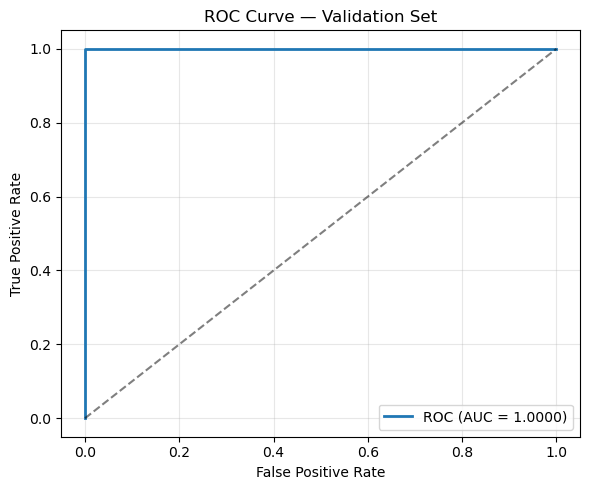

In [15]:
# Prediksi di validation set
y_val_prob = model.predict(val_ds, verbose=0).flatten()
y_val_true = np.array(val_labels)

# Threshold search menggunakan weighted F1
thresholds  = np.linspace(0.1, 0.9, 81)
best_thresh = 0.5
best_f1     = -1

for t in thresholds:
    y_pred_t = (y_val_prob >= t).astype(int)
    report_t = classification_report(
        y_val_true, y_pred_t, output_dict=True, zero_division=0
    )
    f1 = report_t["weighted avg"]["f1-score"]
    if f1 > best_f1:
        best_f1     = f1
        best_thresh = t

print(f"Best threshold (val weighted-F1): {best_thresh:.2f}")
print(f"Best val weighted-F1            : {best_f1:.4f}")
print("[INFO] Threshold dipilih dari VAL set — TEST set belum disentuh.")

# Plot ROC Curve (val)
fpr, tpr, _ = roc_curve(y_val_true, y_val_prob)
auc_val     = roc_auc_score(y_val_true, y_val_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f"ROC (AUC = {auc_val:.4f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Validation Set")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / "roc_curve_val.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 📊 CELL 12 — Evaluasi Akhir di Test Set

> **Test set digunakan SEKALI di sini.** Jangan pernah loop kembali ke tuning setelah melihat hasil ini.

HASIL EVALUASI TEST SET
  Loss        : 0.0000
  Accuracy    : 1.0000  (100.00%)
  AUC (model) : 1.0000
  Threshold   : 0.10  (dipilih dari val set)


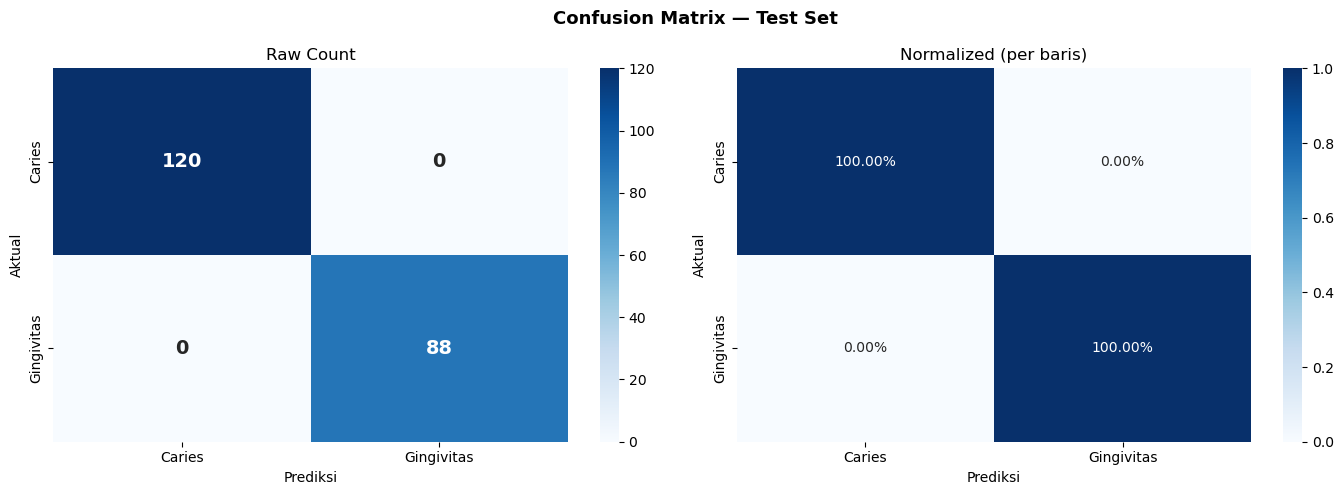


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Caries     1.0000    1.0000    1.0000       120
  Gingivitas     1.0000    1.0000    1.0000        88

    accuracy                         1.0000       208
   macro avg     1.0000    1.0000    1.0000       208
weighted avg     1.0000    1.0000    1.0000       208


📋 Metrik Klinis
  Sensitivity (Recall) : 1.0000
  Specificity          : 1.0000
  False Negative Rate  : 0.0000  ← % kasus tidak terdeteksi
  ✅ Sensitivity >= 80%


2026/05/22 10:56:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/22 10:56:22 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.



✓ Metrik dan artefak dicatat ke MLflow


In [16]:
# Evaluasi model di test set
test_loss, test_acc, test_auc = model.evaluate(test_ds, verbose=0)
print("=" * 45)
print("HASIL EVALUASI TEST SET")
print("=" * 45)
print(f"  Loss        : {test_loss:.4f}")
print(f"  Accuracy    : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  AUC (model) : {test_auc:.4f}")
print(f"  Threshold   : {best_thresh:.2f}  (dipilih dari val set)")
print("=" * 45)

# Prediksi dengan best_threshold
y_prob = model.predict(test_ds, verbose=0).flatten()
y_true = np.array(test_labels)
y_pred = (y_prob >= best_thresh).astype(int)

# Confusion Matrix
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confusion Matrix — Test Set", fontsize=13, fontweight="bold")

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[0],
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title("Raw Count")
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Aktual")

sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title("Normalized (per baris)")
axes[1].set_xlabel("Prediksi")
axes[1].set_ylabel("Aktual")

plt.tight_layout()
plt.savefig(RESULT_DIR / "confusion_matrix_test.png", dpi=150, bbox_inches="tight")
plt.show()

# Classification Report
report_str  = classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0)
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)

print("\nCLASSIFICATION REPORT")
print("=" * 60)
print(report_str)

with open(RESULT_DIR / "classification_report_test.txt", "w") as f:
    f.write(report_str)

# Metrik klinis (penting untuk medical imaging)
if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fnr         = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    print("\n📋 Metrik Klinis")
    print("=" * 45)
    print(f"  Sensitivity (Recall) : {sensitivity:.4f}")
    print(f"  Specificity          : {specificity:.4f}")
    print(f"  False Negative Rate  : {fnr:.4f}  ← % kasus tidak terdeteksi")
    print("=" * 45)
    if sensitivity < 0.80:
        print("  ⚠️  Sensitivity < 80% — pertimbangkan turunkan threshold")
    else:
        print("  ✅ Sensitivity >= 80%")

# Log ke MLflow parent run
with mlflow.start_run(run_id=parent_run_id):
    mlflow.log_metrics({
        "test_accuracy"   : float(test_acc),
        "test_auc"        : float(test_auc),
        "test_loss"       : float(test_loss),
        "test_sensitivity": float(sensitivity) if cm.shape == (2, 2) else -1,
        "test_specificity": float(specificity) if cm.shape == (2, 2) else -1,
        "best_threshold"  : float(best_thresh),
    })
    mlflow.log_artifact(str(RESULT_DIR / "confusion_matrix_test.png"))
    mlflow.log_artifact(str(RESULT_DIR / "classification_report_test.txt"))
    mlflow.keras.log_model(model, "dental_model_final")

print("\n✓ Metrik dan artefak dicatat ke MLflow")

---
## 💾 CELL 13 — Simpan Model & Metadata

In [17]:
# Simpan dalam format native Keras (bukan .h5 yang deprecated)
model.save(str(MODEL_DIR / "dental_mobilenetv2_final.keras"))

metadata = {
    "class_map"     : class_map,
    "idx_to_class"  : {str(v): k for k, v in class_map.items()},
    "img_size"      : list(IMG_SIZE),
    "best_threshold": float(best_thresh),
    "preprocessing" : "tensorflow.keras.applications.mobilenet_v2.preprocess_input",
    "model_base"    : "MobileNetV2",
    "seed"          : SEED,
    "unfreeze_last" : UNFREEZE_LAST,
    "test_accuracy" : float(test_acc),
    "test_auc"      : float(test_auc),
}

with open(MODEL_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("✓ Model   :", MODEL_DIR / "dental_mobilenetv2_final.keras")
print("✓ Metadata:", MODEL_DIR / "metadata.json")
print("\nIsi metadata:")
print(json.dumps(metadata, indent=2))

✓ Model   : D:\Amikom Kuliah\sem 6\datamining\data_dental2.0\models\dental_mobilenetv2_final.keras
✓ Metadata: D:\Amikom Kuliah\sem 6\datamining\data_dental2.0\models\metadata.json

Isi metadata:
{
  "class_map": {
    "Caries": 0,
    "Gingivitas": 1
  },
  "idx_to_class": {
    "0": "Caries",
    "1": "Gingivitas"
  },
  "img_size": [
    224,
    224
  ],
  "best_threshold": 0.1,
  "preprocessing": "tensorflow.keras.applications.mobilenet_v2.preprocess_input",
  "model_base": "MobileNetV2",
  "seed": 42,
  "unfreeze_last": 30,
  "test_accuracy": 1.0,
  "test_auc": 1.0
}


---
## 🔍 CELL 14 — Inference Gambar Baru

In [18]:
# Load metadata
with open(MODEL_DIR / "metadata.json") as f:
    meta = json.load(f)

idx_to_class  = {int(k): v for k, v in meta["idx_to_class"].items()}
inference_thr = meta["best_threshold"]


def predict_image(img_path, threshold=None, show=True):
    """
    Prediksi satu gambar.
    Preprocessing identik dengan training: preprocess_input MobileNetV2.
    """
    if threshold is None:
        threshold = inference_thr

    img       = load_img(img_path, target_size=tuple(meta["img_size"]))
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)   # WAJIB sama dengan training
    img_array = np.expand_dims(img_array, axis=0)

    prob       = float(model.predict(img_array, verbose=0)[0][0])
    pred_idx   = int(prob >= threshold)
    label      = idx_to_class[pred_idx]
    confidence = prob if pred_idx == 1 else (1 - prob)

    if show:
        color = "green" if confidence >= 0.7 else "orange"
        plt.figure(figsize=(4, 4))
        plt.imshow(load_img(img_path))
        plt.title(f"Prediksi: {label}\nConfidence: {confidence:.2%}",
                  fontsize=12, color=color, fontweight="bold")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

    return {"file": str(img_path), "label": label,
            "confidence": confidence, "raw_prob": prob, "threshold": threshold}


def predict_folder(folder_path, threshold=None):
    """Prediksi semua gambar dalam folder, simpan hasil ke CSV."""
    folder_path = Path(folder_path)
    all_imgs    = [p for p in folder_path.rglob("*")
                   if p.suffix.lower() in VALID_EXTENSIONS]

    if not all_imgs:
        print("Tidak ada gambar di:", folder_path)
        return pd.DataFrame()

    results = [predict_image(p, threshold=threshold, show=False)
               for p in sorted(all_imgs)]
    df = pd.DataFrame(results)

    out_path = RESULT_DIR / "folder_predictions.csv"
    df.to_csv(out_path, index=False)
    print(df[["file", "label", "confidence"]].to_string(index=False))
    print(f"\nTotal: {len(df)} | {df['label'].value_counts().to_dict()}")
    print(f"✓ Disimpan ke {out_path}")
    return df


print("✓ predict_image() dan predict_folder() siap")
print(f"  Threshold aktif: {inference_thr:.2f}")
print("  Contoh: result = predict_image('path/gambar.jpg')")
print("  Contoh: df     = predict_folder('./data_test/')")

✓ predict_image() dan predict_folder() siap
  Threshold aktif: 0.10
  Contoh: result = predict_image('path/gambar.jpg')
  Contoh: df     = predict_folder('./data_test/')
